# Graph and Mining
## EDA

### ESILV A5 - CDOF3

OUNES Sarah \
MATTHEWS Louis-Marie\
\
Dataset : Basketball_women.json

---

## Data import

### Exploring Data

First we import all the necessary libraries to clean and analyze the data.

In [ ]:
import pandas as pd
import json 
import matplotlib.pyplot as plt
import numpy as np

Before anything we ensure the JSON file is well-structured and does not contain syntax errors before further processing.

Each object in the JSON file is structured like this: 

```json
{
  "_id": "string", 
  "firstName": "string",
  "middleName": "string or null", 
  "lastName": "string",
  "fullGivenName": "string",
  "nameNick": "string or null",
  "pos": "string (position)",
  "height": "integer",
  "weight": "integer",
  "college": "string or null",
  "birthDate": "string (YYYY-MM-DD)",
  "birthCity": "string or null",
  "birthCountry": "string or null",
  "highSchool": "string or null",
  "hsCity": "string or null",
  "hsState": "string or null",
  "hsCountry": "string or null",
  "players_teams": [
    {
      "year": "integer",
      "tmID": "string",
      "games": "integer",
      "minutes": "integer",
      "points": "integer",
      "steals": "integer",
      "blocks": "integer"
    }
  ],
  "awards_players": [
    {
      "award": "string",
      "year": "integer",
      "pos": "string or null"
    }
  ]
}

We start by opening the JSON file using lines=True, which allows Pandas to directly interpret each line as a separate JSON object. This is particularly useful for newline delimited JSON (NDJSON), where each entry is already structured as an independent JSON object. By doing so, we avoid the need for additional Python scripts to rearrange or restructure the data manually. Then running df.info() immediately provides an overview of the dataset, displaying the column names, data types, and any potential missing values. This ensures that the data is correctly parsed and ready for further processing.

In [ ]:
df = pd.read_json('data/original/Basketball_women.json', lines=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 893 entries, 0 to 892
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   _id             893 non-null    object
 1   firstName       893 non-null    object
 2   middleName      150 non-null    object
 3   lastName        893 non-null    object
 4   fullGivenName   893 non-null    object
 5   nameNick        53 non-null     object
 6   pos             815 non-null    object
 7   height          893 non-null    int64 
 8   weight          893 non-null    int64 
 9   college         726 non-null    object
 10  birthDate       893 non-null    object
 11  birthCity       263 non-null    object
 12  birthCountry    266 non-null    object
 13  highSchool      253 non-null    object
 14  hsCity          253 non-null    object
 15  hsState         249 non-null    object
 16  hsCountry       254 non-null    object
 17  players_teams   893 non-null    object
 18  awards_pla

The dataset has been successfully loaded into a Pandas DataFrame, containing 893 entries across 19 columns. The data types include integer (int64) for numerical values and object for textual data, with some fields having missing values. 

In [1452]:
# Shows first 5 rows
df.head()

,_id,firstName,middleName,lastName,fullGivenName,nameNick,pos,height,weight,college,birthDate,birthCity,birthCountry,highSchool,hsCity,hsState,hsCountry,players_teams,awards_players
0,abrahta01w,Tajama,Ethia,Abraham,Tajama Abraham,"TJ,Taj",C,74,190,George Washington,1975-09-27,"St,Croix",ISV,Kecoughtan,Hampton,VA,USA,"[{'year': 1997, 'tmID': 'SAC', 'games': 28, 'm...",[]
1,abrossv01w,Svetlana,Olegovna,Abrosimova,Svetlana Abrosimova,"Svet,Sveta",F,74,169,Connecticut,1980-07-09,St. Petersburg,URS,Petrogradskoi N86,St. Petersburg,None,RUS,"[{'year': 2001, 'tmID': 'MIN', 'games': 26, 'm...",[]
2,adairje01w,Jessica,Elizabeth,Adair,Jessica Adair,None,C,76,197,George Washington,1986-12-19,Washington,USA,Anacostia Senior,Washington,DC,USA,"[{'year': 2010, 'tmID': 'MIN', 'games': 1, 'mi...",[]
3,adamsda01w,Danielle,E.,Adams,Danielle Adams,None,F-C,73,239,Texas A&M,1989-02-19,Kansas City,USA,Lee's Summit,Lee's Summit,MO,USA,"[{'year': 2011, 'tmID': 'SAS', 'games': 23, 'm...",[]
4,adamsjo01w,Jordan,None,Adams,Jordan Adams,None,C,75,180,New Mexico,1981-05-24,Las Vegas,USA,Moapa Valley,Overton,NV,USA,"[{'year': 2003, 'tmID': 'MIN', 'games': 10, 'm...",[]


Upon examining the dataset, we can see that most standard fields, such as _id, firstName, lastName, height, weight, and birthDate, are well-structured and contain meaningful data. However, some fields require closer inspection, particularly nested data fields like players_teams and awards_players. These fields store lists of dictionaries so since the dataset contains nested fields, we will generate separate CSV files. Another important aspect is identifying missing values. Some fields, such as middleName, nameNick, contain None values, which need to be properly handled to prevent issues during CSV export. Additionally, we need to check for duplicate entries, especially in _id, to ensure uniqueness and avoid inconsistencies when linking the separate CSV files.

### Consistency


Checking for duplicate lines in the dataframe ensures data consistency. Duplicate records can cause redundant storage, slow queries, and data integrity issues, especially when using primary keys. Removing duplicates ensures efficient storage and accurate retrieval.

In [1453]:
# Count the number of unique '_id' values
unique_ids_count = df["_id"].nunique()

# Count the total number of rows
total_rows = len(df)

# Check if the number of unique IDs is equal to the total number of rows
has_duplicates = unique_ids_count != total_rows

# Display the results
print(f"Number of unique IDs: {unique_ids_count}")
print(f"Total number of rows: {total_rows}")
print(f"Are there duplicate IDs? {'Yes' if has_duplicates else 'No'}")

Number of unique IDs: 893
Total number of rows: 893
Are there duplicate IDs? No


Since the number of unique id is equal to the number of rows we can conclude that there are no duplicated object and we can move forward. We will take a closer look to the numerical values in the dataframe.

In [1454]:
# Height are in inches and weights in lbs
df.describe()

,height,weight
count,893.000000,893.000000
mean,65.500560,145.415454
std,20.940425,61.275703
min,0.000000,0.000000
25%,68.000000,140.000000
50%,72.000000,162.000000
75%,75.000000,180.000000
max,80.000000,254.000000


When running df.describe() on our dataset, the output only includes information about height and weight. This is because pandas' describe() function, by default, only processes numerical columns (i.e., columns with int or float data types). Since height and weight are stored as integers, pandas calculates statistical measures such as the mean, standard deviation, min, max, and quartiles for these two variables. The output of df.describe() reveals a potential issue in the dataset. The minimum values for both height and weight are 0, which is not realistic for a dataset related to human measurements. This suggests that there might be errors or missing data incorrectly recorded as zero.

In [1455]:
# Display rows where both height and weight are 0
invalid_rows = df[(df["height"] == 0) | (df["weight"] == 0)]
invalid_rows

,_id,firstName,middleName,lastName,fullGivenName,nameNick,pos,height,weight,college,birthDate,birthCity,birthCountry,highSchool,hsCity,hsState,hsCountry,players_teams,awards_players
5,adamsmi01w,Michael,None,Adams,Michael Adams,None,None,0,0,None,0000-00-00,None,None,None,None,None,None,[],[]
6,adubari99w,Richie,None,Adubato,Richie Adubato,None,None,0,0,None,0000-00-00,None,None,None,None,None,None,[],[]
7,aglerbr99w,Brian,None,Alger,Brian Agler,None,None,0,0,None,0000-00-00,None,None,None,None,None,None,[],"[{'award': 'Coach of the Year', 'year': 1997, ..."
10,alberma01w,Marcie,None,Alberts,Marcie Alberts,None,G,64,0,Ohio State,1975-04-12,Wooster,USA,Orrville,Orrville,OH,USA,"[{'year': 1997, 'tmID': 'CLE', 'games': 5, 'mi...",[]
15,allenso99w,Sonny,None,Allen,Sonny Allen,None,None,0,0,None,0000-00-00,None,None,None,None,None,None,[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
857,willisa01w,Samantha,None,Williams,Samantha Williams,None,G-F,72,0,Auburn,1973-09-24,None,None,None,None,None,None,"[{'year': 1997, 'tmID': 'SJL', 'games': 25, 'm...",[]
863,wintebr01w,Brian,None,Winters,Brian Winters,None,None,0,0,None,0000-00-00,None,None,None,None,None,None,[],[]
871,woodki01w,Kimberly,None,Wood,Kimberly Wood,None,C,76,0,Wisconsin-Green Bay,1972-09-16,None,None,None,None,None,None,"[{'year': 1997, 'tmID': 'SJL', 'games': 32, 'm...",[]
872,woolror01w,Orlando,None,Woolridge,Orlando Woolridge,None,None,0,0,None,0000-00-00,None,None,None,None,None,None,[],[]


Since some records with height and weight equal to 0 might still contain useful information in the players_teams or awards_players fields, we decided not to delete these rows. Instead, we replaced 0 values with None to indicate missing data while preserving the rest of the record. This approach allows us to retain potentially useful records while ensuring data integrity and flexibility for future updates.

In [ ]:
# Replace 0 values in 'height' and 'weight' columns with None 
df["height"] = df["height"].replace(0, None)
df["weight"] = df["weight"].replace(0, None)

Then we could check birthDate. Any entry that does not follow the expected YYYY-MM-DD format, such as 0000-00-00, needs to be identified and corrected before importing the data. This ensures that the data is correctly stored and avoids errors during insertion.

In [1457]:
# Attempt to convert 'birthDate' to a valid datetime format
df['birthDate'] = pd.to_datetime(df['birthDate'], errors='coerce')

# Identify rows where the date conversion failed (invalid dates)
invalid_dates = df[df['birthDate'].isna()]

invalid_dates

,_id,firstName,middleName,lastName,fullGivenName,nameNick,pos,height,weight,college,birthDate,birthCity,birthCountry,highSchool,hsCity,hsState,hsCountry,players_teams,awards_players
5,adamsmi01w,Michael,None,Adams,Michael Adams,None,None,None,None,None,NaT,None,None,None,None,None,None,[],[]
6,adubari99w,Richie,None,Adubato,Richie Adubato,None,None,None,None,None,NaT,None,None,None,None,None,None,[],[]
7,aglerbr99w,Brian,None,Alger,Brian Agler,None,None,None,None,None,NaT,None,None,None,None,None,None,[],"[{'award': 'Coach of the Year', 'year': 1997, ..."
15,allenso99w,Sonny,None,Allen,Sonny Allen,None,None,None,None,None,NaT,None,None,None,None,None,None,[],[]
52,beckan99wc,Angela,None,Beck,Angela Beck,None,None,None,None,None,NaT,None,None,None,None,None,None,[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
848,willifr99w,Fred,None,Williams,Fred Williams,None,None,None,None,None,NaT,None,None,None,None,None,None,[],[]
849,willigr99w,Greg,None,Williams,Greg Williams,None,None,None,None,None,NaT,None,None,None,None,None,None,[],[]
863,wintebr01w,Brian,None,Winters,Brian Winters,None,None,None,None,None,NaT,None,None,None,None,None,None,[],[]
872,woolror01w,Orlando,None,Woolridge,Orlando Woolridge,None,None,None,None,None,NaT,None,None,None,None,None,None,[],[]


In [1458]:
# Remove rows where 'birthDate' is invalid (cannot be converted) or out of range
df = df.drop(invalid_dates.index)
df.head(10)

,_id,firstName,middleName,lastName,fullGivenName,nameNick,pos,height,weight,college,birthDate,birthCity,birthCountry,highSchool,hsCity,hsState,hsCountry,players_teams,awards_players
0,abrahta01w,Tajama,Ethia,Abraham,Tajama Abraham,"TJ,Taj",C,74,190,George Washington,1975-09-27,"St,Croix",ISV,Kecoughtan,Hampton,VA,USA,"[{'year': 1997, 'tmID': 'SAC', 'games': 28, 'm...",[]
1,abrossv01w,Svetlana,Olegovna,Abrosimova,Svetlana Abrosimova,"Svet,Sveta",F,74,169,Connecticut,1980-07-09,St. Petersburg,URS,Petrogradskoi N86,St. Petersburg,None,RUS,"[{'year': 2001, 'tmID': 'MIN', 'games': 26, 'm...",[]
2,adairje01w,Jessica,Elizabeth,Adair,Jessica Adair,None,C,76,197,George Washington,1986-12-19,Washington,USA,Anacostia Senior,Washington,DC,USA,"[{'year': 2010, 'tmID': 'MIN', 'games': 1, 'mi...",[]
3,adamsda01w,Danielle,E.,Adams,Danielle Adams,None,F-C,73,239,Texas A&M,1989-02-19,Kansas City,USA,Lee's Summit,Lee's Summit,MO,USA,"[{'year': 2011, 'tmID': 'SAS', 'games': 23, 'm...",[]
4,adamsjo01w,Jordan,None,Adams,Jordan Adams,None,C,75,180,New Mexico,1981-05-24,Las Vegas,USA,Moapa Valley,Overton,NV,USA,"[{'year': 2003, 'tmID': 'MIN', 'games': 10, 'm...",[]
8,aguilel01w,Elisabeth,None,Aguilar Lopez,Elisa Aguilar,Elisa,G,67,165,George Washington,1976-10-15,Madrid,ESP,None,None,None,None,"[{'year': 2002, 'tmID': 'UTA', 'games': 28, 'm...",[]
9,ajavoma01w,Matee,None,Ajavon,Matee Ajavon,None,G,68,160,Rutgers,1986-05-07,Monrovia,LBR,Malcolm X. Shabazz,Newark,NJ,USA,"[{'year': 2008, 'tmID': 'HOU', 'games': 34, 'm...",[]
10,alberma01w,Marcie,None,Alberts,Marcie Alberts,None,G,64,None,Ohio State,1975-04-12,Wooster,USA,Orrville,Orrville,OH,USA,"[{'year': 1997, 'tmID': 'CLE', 'games': 5, 'mi...",[]
11,aldrima01w,Markita,None,Aldridge,Markita Aldridge,Kita,G,71,153,UNC Charlotte,1973-09-15,Detroit,USA,Martin Luther King,Detroit,MI,USA,"[{'year': 1997, 'tmID': 'COL', 'games': 15, 'm...",[]
12,alexaer01w,Erin,None,Alexander,Erin Alexander,None,G,67,140,California-Santa Barbara,1975-04-25,Santa Ynez,USA,Santa Ynez,Santa Ynez,CA,USA,"[{'year': 1998, 'tmID': 'LAS', 'games': 8, 'mi...",[]


With duplicates removed and invalid height and weight values filtered out, we can now check for outliers in the dataset. 

### Outliers

First, we will check if the date values fall within a conventional time frame, ensuring that birthdates are realistic (e.g., no players born in the 1800s or after 2010). This step prevents data inconsistencies that could affect queries and analytics. After verifying dates, we can proceed to check for outliers in other numerical fields to maintain data quality before exporting to CSV.

In [1459]:
# Convert birthDate to datetime format
df["birthDate"] = pd.to_datetime(df["birthDate"], errors="coerce")  # Coerce invalid dates to NaT

# Define valid date range (e.g., between 1900 and 2010)
start_date = "1900-01-01"
end_date = "2010-12-31"

# Identify rows with invalid birth dates
invalid_dates = df[(df["birthDate"] < start_date) | (df["birthDate"] > end_date) | df["birthDate"].isna()]

# Display invalid birth dates
invalid_dates

,_id,firstName,middleName,lastName,fullGivenName,nameNick,pos,height,weight,college,birthDate,birthCity,birthCountry,highSchool,hsCity,hsState,hsCountry,players_teams,awards_players


Since all birth dates fall within a valid range, we can now proceed to detect outliers in height and weight. Outliers in these fields may indicate data entry errors or extreme values that could distort queries and analytics. We will use the Interquartile Range (IQR) method to identify and, if necessary, remove these anomalies before exporting the dataset.

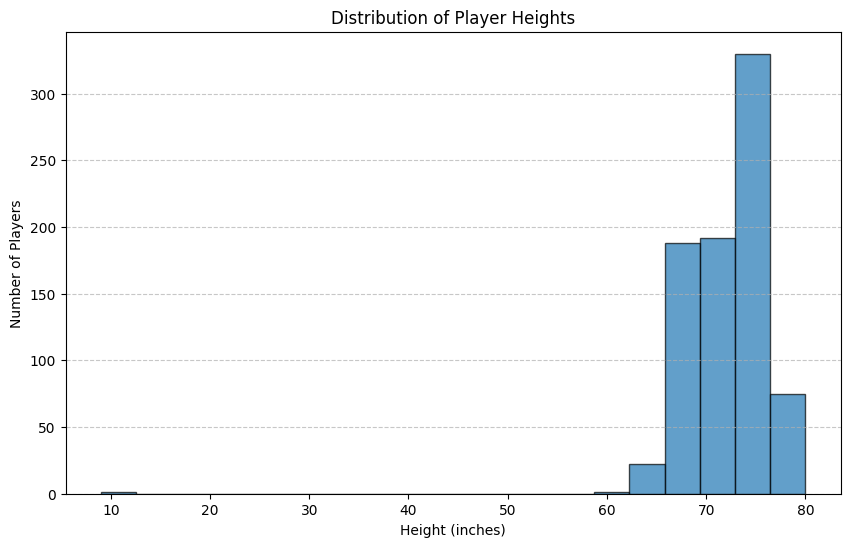

In [1460]:
# Plot distribution of heights
plt.figure(figsize=(10, 6))
plt.hist(df["height"], bins=20, edgecolor="black", alpha=0.7)
plt.xlabel("Height (inches)")
plt.ylabel("Number of Players")
plt.title("Distribution of Player Heights")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()

The previous height distribution graph revealed impossible values, with some players having heights below 20 inches, which is unrealistic for basketball players. To maintain data integrity, we decided to remove all rows where height is less than 50 inches, ensuring that our dataset remains accurate and meaningful. 

In [1461]:
# Remove rows where height is below a reasonable threshold (e.g., 50 inches)
df = df[df["height"] >= 50]

We now proceed the same way for weights.

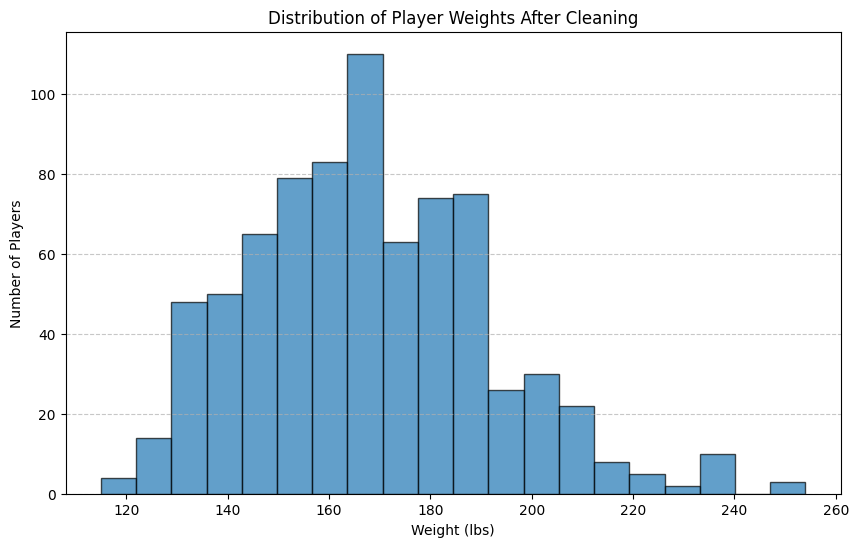

In [1462]:
# Plot distribution of weights
df_plot =  df["weight"].dropna()
plt.figure(figsize=(10, 6))
plt.hist(df_plot, bins=20, edgecolor="black", alpha=0.7)  # Drop NaN values for visualization
plt.xlabel("Weight (lbs)")
plt.ylabel("Number of Players")
plt.title("Distribution of Player Weights After Cleaning")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Show the plot
plt.show()

The weight distribution graph shows that the recorded values fall within a plausible range, meaning there are no extreme or unrealistic outliers. Since the data appears consistent, we can move forward with further preprocessing and prepare the dataset for export by handling the missing values.

### Handling missing values

Before converting the dataset into CSV it is necessary to handle missing values, NaN values need to be replaced with None to avoid issues during insertion.

In [1463]:
# Convert birthDate to object (string format)
df["birthDate"] = df["birthDate"].astype("object")
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 808 entries, 0 to 892
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   _id             808 non-null    object
 1   firstName       808 non-null    object
 2   middleName      149 non-null    object
 3   lastName        808 non-null    object
 4   fullGivenName   808 non-null    object
 5   nameNick        51 non-null     object
 6   pos             808 non-null    object
 7   height          808 non-null    object
 8   weight          771 non-null    object
 9   college         719 non-null    object
 10  birthDate       808 non-null    object
 11  birthCity       262 non-null    object
 12  birthCountry    265 non-null    object
 13  highSchool      251 non-null    object
 14  hsCity          251 non-null    object
 15  hsState         247 non-null    object
 16  hsCountry       252 non-null    object
 17  players_teams   808 non-null    object
 18  awards_players 

In [ ]:
# Replace NaN with None
df = df.where(pd.notnull(df), None)

# Counts missing (None) values per column
df.isnull().sum() 

_id                 0
firstName           0
middleName        659
lastName            0
fullGivenName       0
nameNick          757
pos                 0
height              0
weight             37
college            89
birthDate           0
birthCity         546
birthCountry      543
highSchool        557
hsCity            557
hsState           561
hsCountry         556
players_teams       0
awards_players      0
dtype: int64

From the analysis of missing values, we observe that 757 out of 808 rows in the nameNick column are None, meaning that this field is missing in approximately 94% of the dataset. Similarly, the middleName column has 659 missing values out of 808, accounting for 83% of the dataset. Given the high percentage of missing values in both columns, they do not provide significant information and can be dropped to optimize data storage and processing.

Other columns, such as birthCity, birthCountry, and highSchool, also have a considerable number of missing values, but further analysis is required to determine their importance and whether they should be retained or removed.

In [1465]:
# Drop 'nameNick' and 'middleName' columns
df.drop(columns=['nameNick', 'middleName'], inplace=True)

# Verify that the columns are removed
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 808 entries, 0 to 892
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   _id             808 non-null    object
 1   firstName       808 non-null    object
 2   lastName        808 non-null    object
 3   fullGivenName   808 non-null    object
 4   pos             808 non-null    object
 5   height          808 non-null    object
 6   weight          771 non-null    object
 7   college         719 non-null    object
 8   birthDate       808 non-null    object
 9   birthCity       262 non-null    object
 10  birthCountry    265 non-null    object
 11  highSchool      251 non-null    object
 12  hsCity          251 non-null    object
 13  hsState         247 non-null    object
 14  hsCountry       252 non-null    object
 15  players_teams   808 non-null    object
 16  awards_players  808 non-null    object
dtypes: object(17)
memory usage: 113.6+ KB


After analyzing missing values per column, we now examine the number of missing values per row. This allows us to identify individual records that have too many empty fields or empty lists ([]).

In [1466]:
# Function to count missing values and empty lists for specific columns
def count_specific_missing_values(row):
    missing_count = 0

    # Check if 'players_teams' is an empty list
    if isinstance(row["players_teams"], list) and len(row["players_teams"]) == 0:
        missing_count += 1

    # Check if specific columns are null
    columns_to_check = ["weight", "birthCity", "birthCountry", "highSchool", "hsCity", "hsState", "hsCountry"]
    missing_count += sum(pd.isnull(row[col]) for col in columns_to_check)

    return missing_count

# Create a list of tuples (row index, missing values count) for rows with more than 7 missing values
missing_values_list = [(index, count_specific_missing_values(row)) for index, row in df.iterrows() if count_specific_missing_values(row) > 7]

missing_values_list

[]

The analysis of missing values per row shows that while some rows contain multiple missing values, there are no rows with all values missing. This indicates that every record retains some useful information. Since we do not have completely empty rows, we can proceed with further processing without the need to remove any rows entirely. The next step involves handling the unique values and nested fields before converting the dataset into separate CSV files.

### Unique values

The next step is to analyze the unique values in each column to better understand the dataset. This helps in identifying categorical variables, spotting inconsistencies, and understanding data distribution.

Since players_teams and awards_players are nested columns containing lists of dictionaries, they cannot be analyzed using the .unique() function. The .unique() function in Pandas works only with hashable types (such as strings, integers, or floats), whereas lists and dictionaries are unhashable and cannot be directly processed in this way.

In [1467]:
# Exclude nested columns before checking unique values
excluded_columns = ["players_teams", "awards_players"]
selected_columns = [col for col in df.columns if col not in excluded_columns]

# Count the number of unique values per column
df[selected_columns].nunique()

_id              808
firstName        586
lastName         663
fullGivenName    808
pos                7
height            19
weight           103
college          159
birthDate        762
birthCity        215
birthCountry      34
highSchool       240
hsCity           200
hsState           47
hsCountry          9
dtype: int64

In [1468]:
# Display unique values for selected categorical columns
df["pos"].unique()

array(['C', 'F', 'F-C', 'G', 'F-G', 'G-F', 'C-F'], dtype=object)

In [1469]:
# Display unique values for selected categorical columns
df["hsCountry"].unique()

array(['USA', 'RUS', None, 'BRA', 'CAN', 'URS', 'BUL', 'AUS', 'COD',
       'JPN'], dtype=object)

In [1470]:
# Display unique values for selected categorical columns
df["college"].unique()

array(['George Washington', 'Connecticut', 'Texas A&M', 'New Mexico',
       'Rutgers', 'Ohio State', 'UNC Charlotte',
       'California-Santa Barbara', 'DePaul', 'Notre Dame', None,
       'Arizona State', 'Brigham Young', 'Vanderbilt', 'Wisconsin',
       'Old Dominion', 'Tennessee', 'Stanford', 'none', 'Northeastern',
       'North Carolina', 'Louisiana State', 'Kansas', 'Pepperdine',
       'Syracuse', 'Boise State', 'California', 'Georgia', 'Duke',
       'Washington', 'Academy of Sport Moscow', 'Arizona', 'Indiana',
       'Montana State', 'Florida International', 'Rice', 'Illinois',
       'Iowa', 'Colorado', "St. Joseph's", 'Maine', 'UCLA', 'Miami (FL)',
       'Auburn', 'Louisiana Tech', 'Missouri', 'Illinois State',
       'Virginia', 'Michigan State', 'Oral Roberts', 'Texas Tech',
       'U. Western Sydney', 'Long Beach State', 'Texas', 'Furman',
       'Penn State', 'Georgetown', 'Maryland', 'Alabama', 'Tulane',
       'Eastern Michigan', 'Central Florida CC', 'USC', 'Okla

In [1471]:
# Extract unique awards
unique_awards = set()

# Open and process the NDJSON file (each line is a separate JSON object)
with open(JSON_FILENAME, "r", encoding="utf-8") as file:
    for line in file:  # Read each JSON object as a line
        player = json.loads(line)  # Convert string to dictionary
        for award in player.get("awards_players", []):  # Check if awards exist
            unique_awards.add(award["award"])

# Display all possible awards
print("List of unique awards:")
for award in sorted(unique_awards):
    print(f"- {award}")


List of unique awards:
- ABL Playoffs Most Valuable Player
- All-Star Game Most Valuable Player
- Coach of the Year
- Defensive Player of the Year
- Kim Perrot Sportsmanship
- Kim Perrot Sportsmanship Award
- Most Improved Player
- Most Valuable Player
- New Pro Award
- Newcomer of the Year
- Peak Performer: Assists
- Peak Performer: Points
- Peak Performer: Rebounds
- Rookie of the Year
- Sixth Woman of the Year
- WNBA All Decade Team Honorable Mention
- WNBA All-Decade Team
- WNBA Finals Most Valuable Player


The extracted list of unique awards shows that "Kim Perrot Sportsmanship" and "Kim Perrot Sportsmanship Award" likely refer to the same award, with the second version simply including the word "Award" in its name. To maintain consistency in the dataset and avoid duplicate representations of the same award, we will standardize this by removing "Award" from the second variant and keeping only "Kim Perrot Sportsmanship".

In [ ]:
# Function to standardize the award name in the DataFrame
def clean_award_name(awards):
    if isinstance(awards, list):  # Ensure it's a list before processing
        for award in awards:
            if isinstance(award, dict) and award.get("award") == "Kim Perrot Sportsmanship Award":
                award["award"] = "Kim Perrot Sportsmanship"  # Standardize the award name
    return awards

# Apply the function to standardize awards in the DataFrame
df["awards_players"] = df["awards_players"].apply(clean_award_name)

JSON data successfully updated and saved as 'corrected_df_fixed.json'.


In [1473]:
# Extract unique awards from awards_players
unique_awards = set()

for awards_list in df["awards_players"]:
    if isinstance(awards_list, list):  # Ensure the field is a list
        for award in awards_list:
            if isinstance(award, dict) and "award" in award:
                unique_awards.add(award["award"])

# Display unique team IDs
print("List of unique awards:")
for award in sorted(unique_awards):
    print(f"- {award}")

List of unique awards:
- ABL Playoffs Most Valuable Player
- All-Star Game Most Valuable Player
- Coach of the Year
- Defensive Player of the Year
- Kim Perrot Sportsmanship
- Most Improved Player
- Most Valuable Player
- New Pro Award
- Newcomer of the Year
- Peak Performer: Assists
- Peak Performer: Points
- Peak Performer: Rebounds
- Rookie of the Year
- Sixth Woman of the Year
- WNBA All Decade Team Honorable Mention
- WNBA All-Decade Team
- WNBA Finals Most Valuable Player


Now, we attempted to extract the unique tmID values directly from the DataFrame instead of working with the JSON file itself. By processing the players_teams column within the DataFrame, we were able to iterate over the lists of dictionaries stored in each row and extract unique team identifiers efficiently. This approach avoids unnecessary conversions between JSON and Pandas while ensuring that all data manipulations remain within the DataFrame.

In [1474]:
# Extract unique teams (tmID) from players_teams
unique_teams = set()

for player in df["players_teams"]:
    if isinstance(player, list):  # Ensure the field is a list
        for team in player:
            if isinstance(team, dict) and "tmID" in team:
                unique_teams.add(team["tmID"])

# Display unique team IDs
print("List of unique teams (tmID):")
for team in sorted(unique_teams):
    print(f"- {team}")

List of unique teams (tmID):
- ATG
- ATL
- CHA
- CHC
- CHI
- CLE
- CLS
- COL
- CON
- DET
- HOU
- IND
- LAS
- LON
- MIA
- MIN
- NAS
- NEW
- NYL
- ORL
- PHO
- PHR
- POR
- PRT
- RIC
- SAC
- SAS
- SEA
- SER
- SJL
- TUL
- UTA
- WAS


Now, we will determine the maximum number of awards received by a single player and identify which player received those awards. Instead of working with the JSON file directly, we will adapt the code to operate within the DataFrame. This allows us to efficiently analyze the dataset without needing to reload the JSON file, keeping all operations within Pandas.

In [1475]:
# Determine the maximum number of awards received by any player
max_awards = df["awards_players"].apply(lambda x: len(x) if isinstance(x, list) else 0).max()

# Identify players who received this maximum number of awards
players_with_max_awards = df[df["awards_players"].apply(lambda x: len(x) if isinstance(x, list) else 0) == max_awards]

# Display the maximum number of awards
print(f"Maximum number of awards received by a player: {max_awards}")

# Display the awards for the player(s) with the most awards
for _, row in players_with_max_awards.iterrows():
    print(f"Player: {row['fullGivenName']} ({row['_id']})")
    print("Awards:")
    for award in row["awards_players"]:
        print(f" - {award['award']} ({award['year']})")
    print()


Maximum number of awards received by a player: 11
Player: Lisa Leslie (leslili01w)
Awards:
 - All-Star Game Most Valuable Player (1999)
 - All-Star Game Most Valuable Player (2001)
 - All-Star Game Most Valuable Player (2002)
 - Defensive Player of the Year (2004)
 - Defensive Player of the Year (2008)
 - Most Valuable Player (2001)
 - Most Valuable Player (2004)
 - Most Valuable Player (2006)
 - WNBA Finals Most Valuable Player (2001)
 - WNBA Finals Most Valuable Player (2002)
 - WNBA All-Decade Team (2006)



Now, we will determine the maximum number of teams (tmID) a player has been in and identify which player(s) played for the most teams. 

In [1476]:
# Determine the maximum number of teams a player has played for
max_teams = df["players_teams"].apply(lambda x: len(x) if isinstance(x, list) else 0).max()

# Identify players who played for this maximum number of teams
players_with_max_teams = df[df["players_teams"].apply(lambda x: len(x) if isinstance(x, list) else 0) == max_teams]

# Display the maximum number of teams
print(f"Maximum number of teams a player has played for: {max_teams}")

# Display the teams for the player(s) with the most teams
for _, row in players_with_max_teams.iterrows():
    print(f"Player: {row['fullGivenName']} ({row['_id']})")
    print("Teams:")
    for team in row["players_teams"]:
        print(f" - {team['tmID']} ({team['year']})")
    print()


Maximum number of teams a player has played for: 18
Player: Taj McWilliams-Franklin (mcwilta01w)
Teams:
 - RIC (1997)
 - PHR (1998)
 - PHR (1999)
 - ORL (1999)
 - ORL (2000)
 - ORL (2001)
 - ORL (2002)
 - CON (2003)
 - CON (2004)
 - CON (2005)
 - CON (2006)
 - LAS (2007)
 - DET (2008)
 - WAS (2008)
 - DET (2009)
 - NYL (2010)
 - MIN (2011)
 - MIN (2012)

Player: Katie Smith (smithka01w)
Teams:
 - CLS (1997)
 - CLS (1998)
 - CLS (1999)
 - MIN (1999)
 - MIN (2000)
 - MIN (2001)
 - MIN (2002)
 - MIN (2003)
 - MIN (2004)
 - DET (2005)
 - MIN (2005)
 - DET (2006)
 - DET (2007)
 - DET (2008)
 - DET (2009)
 - WAS (2010)
 - SEA (2011)
 - SEA (2012)



These key insights,identifying the player with the most awards and the player who played for the most teams,provide valuable information that enhances our understanding of the dataset. These statistics help highlight outliers, career longevity, and player achievements, which are crucial elements when structuring the data for further analysis. 

### Flatten nested data

In this notebook, we focused on preparing the data and exporting it into structured CSV files. After loading and inspecting the raw dataset, we selected the relevant fields and applied basic preprocessing steps to ensure consistency and correctness. The processed data was then split into several CSV files, each corresponding to a specific subset or use case, so they can be easily reused for testing, analysis, and downstream processing.

In [ ]:
df = pd.read_json('data/original/Basketball_women.json', lines=True)
df.iloc[0]

In [ ]:
df_high_schools = pd.DataFrame(index=df['highSchool'].unique())
df_high_schools.to_csv('data/transformed/high_schools.csv', index_label="HighSchool")
df_high_schools

Node types are:
- Player
- College
- High school
- Team

In [ ]:
df_colleges = pd.DataFrame(index=df['college'].unique())
df_colleges.to_csv('data/transformed/colleges.csv', index_label="College")
df_colleges

In [ ]:
# These relationships are complex, we will add them later with Cypher code
df_players = df.drop(columns=['players_teams', 'awards_players'])
df_players = df_players.set_index('_id')
df_players.to_csv('data/transformed/players.csv')
df_players

#### Players' teams

In [ ]:
tmp = df[['_id', 'players_teams']].explode('players_teams', ignore_index=True)
df_r_teams = pd.json_normalize(tmp['players_teams']).astype({'year': pd.Int64Dtype(), 'games': pd.Int64Dtype(), 'minutes': pd.Int64Dtype(), 'points': pd.Int64Dtype(), 'steals': pd.Int64Dtype(), 'blocks': pd.Int64Dtype()})
df_r_teams['playerId'] = tmp['_id']
df_r_teams.dropna(inplace=True)
df_r_teams.to_csv('data/transformed/players_teams.csv', index_label="relId")

#### Awards

In [ ]:
tmp = df[['_id', 'awards_players']].explode('awards_players', ignore_index=True)
df_r_awards = pd.json_normalize(tmp['awards_players']).astype({'year': pd.Int64Dtype()})
df_r_awards['playerId'] = tmp['_id']
df_r_awards.dropna(inplace=True)
df_r_awards.to_csv('data/transformed/awards.csv', index_label="relId")
df_r_awards